# Paper Plots/Animations

Plots for the upcoming paper; most of which are found in other notebooks in this repository, but just putting them all here to have a record.

In [83]:
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
from pathlib import Path
import os
import matplotlib.path as mpath
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import pandas as pd
from matplotlib.cm import prism
from matplotlib.cm import Set3
import numpy as np
from scipy import stats

curwd = os.getcwd()
os.chdir(str(Path(os.getcwd()).parents[0]) + '/scripts/')
import utils
from utils import display_catalog
os.chdir(str(Path(os.getcwd())) + '/clustering/')
import st_dbscan as st
os.chdir(curwd)
home_dir = Path(curwd).parents[0]


## Main Paper

### Tracker

#### Algorithm Details

Showing how stage 1 of the two-stage clustering works.

In [84]:
catalogs = utils.load_catalogs(years=[1980])

In [85]:
subcatalog = catalogs.isel(time=slice(120, 140))

# hyperparameters  
synoptic_scale = 10**3
km_per_radian = 6.371*(10**3) # arclength (km) on earth subtended by 1 radian

eps_space = synoptic_scale/(2*km_per_radian) # converted to radians for Haversine metric
eps_space_1 = eps_space
eps_space_2 = eps_space
eps_time = 18/24
minpts_1 = 5
minpts_2 = 5
n_rep_pts = 10

# instantiating the clustering object
cluster_obj = st.ST_DBSCAN(eps_space_1, eps_space_2, eps_time, minpts_1, minpts_2, n_rep_pts)
# doing the spatiotemporal clustering
df = cluster_obj.fit(subcatalog)

Beginning spatial clustering step.


100%|██████████| 20/20 [00:02<00:00,  7.53it/s]
/accounts/grad/butlerj/extreme_antarctic_ARs/scripts/clustering/st_dbscan.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ar_pt_df['cluster'] = np.full(cluster_infos_df.shape[0], np.nan)


Beginning spatiotemporal clustering step.


In [86]:
time = df.iloc[9].time

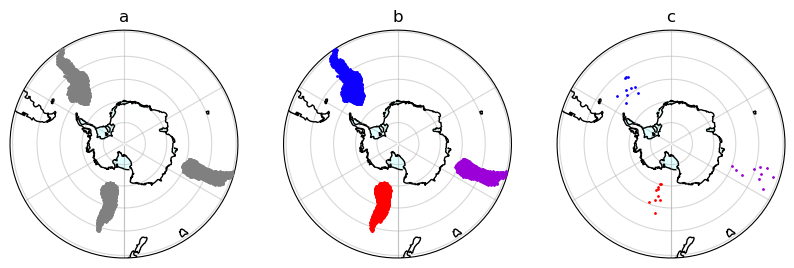

In [87]:
# instantiate the animation
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))

unique_clusters = df['cluster'].unique()
color_mapping = {unique_clusters[j]:prism(j/12) for j in range(len(unique_clusters)) }

if (time == df.time).any():
    dat = df[df['time'] == time]
    n_clusts = dat.shape[0]

    for i in range(n_clusts):
        cluster = dat['cluster'].iloc[i]
        ax[0].scatter(dat['lons'].iloc[i], dat['lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color='gray', zorder=30)
        ax[1].scatter(dat['lons'].iloc[i], dat['lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[cluster], label=str(cluster), zorder=30)
        ax[2].scatter(dat['rep_lons'].iloc[i], dat['rep_lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[cluster], label=str(cluster), zorder=30)

for i in range(len(ax)):

    ax[i].set_extent([-180,180,-90,-39], ccrs.PlateCarree())
    ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
    ax[i].add_feature(ice_shelf_poly,linewidth=3)
    ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
    ax[i].add_feature(ice_shelf_line,linewidth=1,zorder=13)
    ax[i].coastlines(resolution='110m',linewidth=1,zorder=32)

    
    # Map extent 
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax[i].set_boundary(circle, transform=ax[i].transAxes)
    ax[i].gridlines(alpha=0.5, zorder=33)
    
    time_ts = pd.Timestamp(time)
    
ax[0].set_title('a')
ax[1].set_title('b')
ax[2].set_title('c')

plt.savefig('../plots/paper_plots/spatial_clustering.png', bbox_inches='tight')

Showing how stage 2 of the clustering algorithm works.

In [88]:
unpacked_df = cluster_obj.unpack_df(df, 'cluster')

In [89]:
unpacked_df = unpacked_df[unpacked_df.time.dt.day == 8]

In [90]:
unpacked_df = unpacked_df[unpacked_df.time.dt.hour % 6 == 0]

In [91]:
ais_mask = np.radians(np.array(list(utils.load_ais())))

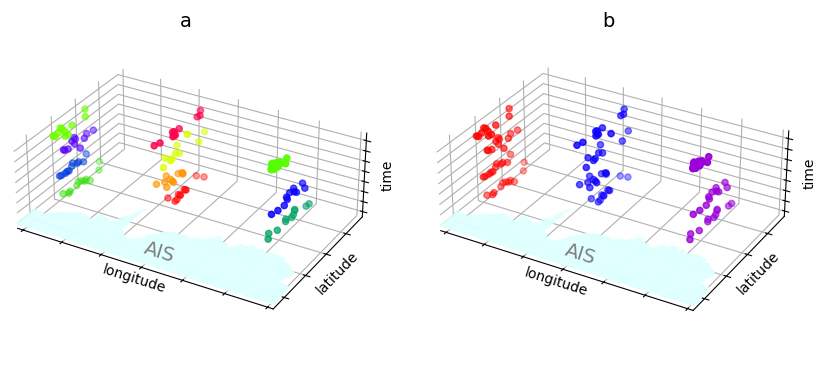

In [92]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,2,2, projection='3d')
ax.scatter(unpacked_df.lon, unpacked_df.lat, unpacked_df.time.dt.hour, c=prism((unpacked_df.cluster-1)/12))
ax.scatter(ais_mask[:,1], ais_mask[:,0], 0, c='lightcyan', s=0.5, zorder=30)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel('longitude', labelpad=-12)
ax.set_ylabel('latitude', labelpad=-12)
ax.set_zlabel('time', rotation=90, labelpad=-12)
ax.axes.set_ylim3d(bottom=min(ais_mask[:,0]))
ax.axes.set_xlim3d(left=min(ais_mask[:,1]))
ax.axes.set_xlim3d(right=max(ais_mask[:,1]))
ax.view_init(azim=-60, elev=30)
ax.set_box_aspect((1.45, 1, 0.5))
ax.text(x=0, y=-1.5, z=0, s='AIS', zorder=31, c='gray', zdir='x', fontsize=14)
ax.set_title('b', fontsize=14, y=1.01)

ax = fig.add_subplot(1,2,1, projection='3d')
ax.scatter(unpacked_df.lon, unpacked_df.lat, unpacked_df.time.dt.hour, c=prism((unpacked_df.space_cluster-1)/20))
ax.scatter(ais_mask[:,1], ais_mask[:,0], 0, c='lightcyan', s=0.5)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel('longitude', labelpad=-12)
ax.set_ylabel('latitude', labelpad=-12)
ax.set_zlabel('time', rotation=90, labelpad=-12)
ax.axes.set_ylim3d(bottom=min(ais_mask[:,0]))
ax.axes.set_xlim3d(left=min(ais_mask[:,1]))
ax.axes.set_xlim3d(right=max(ais_mask[:,1]))
ax.view_init(azim=-60, elev=30)
ax.set_title('a', fontsize=14, y=1.01)
ax.set_box_aspect((1.5, 1, 0.5))
ax.text(x=0, y=-1.5, z=0, s='AIS', zorder=31, c='gray', zdir='x', fontsize=14);

plt.savefig('../plots/paper_plots/spatiotemporal_stitching.png', bbox_inches='tight')

#### Catalog Summaries

In [93]:
catalog_path = '/scratch/users/butlerj/extreme_antarctic_ars/sensitivity_analysis/all_years/seed_12345eps_time_12eps_space_0.5rep_pts_10min_pts_5/storm_df.h5'
full_catalog = pd.read_hdf(catalog_path)

In [94]:
def compute_duration(ar_da):
    days = (ar_da.time.max() - ar_da.time.min()).values.astype('timedelta64[h]').astype(int) + np.timedelta64(3, 'h')
    return days

def add_start_date(ar_da):
    start = ar_da.time.min().values
    return start

def add_end_date(ar_da):
    end = ar_da.time.max().values
    return end

In [95]:
full_catalog['duration'] = full_catalog['data_array'].apply(compute_duration)
full_catalog['start_date'] = full_catalog['data_array'].apply(add_start_date)
full_catalog['end_date'] = full_catalog['data_array'].apply(add_end_date)

In [96]:
ar_mask = xr.open_dataset('~/extreme_antarctic_ARs/data/antarctic_masks/AIS_Full_basins_Zwally_MERRA2grid_new.nc')
ar_mask = ar_mask.Zwallybasins > 0

In [97]:
# region definitions from Wisconsin folks
region_defs = {'MBL': [-150, -120], 
               'ELS': [-120, -75],
               'AP': [-75, -50],
               'FRIS': [-50, -30],
               'QML': [-30, 30],
               'END': [30, 75],
               'QMC': [80, 120],
               'WLK': [120, 150],
               'VICT': [150, 180],
               'RIS': [-180, -150]}

region_masks = {}

for label, bound in region_defs.items():
    region_masks[label] = ar_mask.where((ar_mask.lon > bound[0]) & (ar_mask.lon < bound[1]), False)

In [98]:
cell_areas = xr.open_dataset('~/extreme_antarctic_ARs/data/area/MERRA2_gridarea.nc')
cell_areas = cell_areas.cell_area
cell_areas = cell_areas.assign_coords(lat=cell_areas.lat.round(5), lon=cell_areas.lon.round(5))
# TO CHECK: ISSUES WITH THE AIS MASK AND NOT CONVERTING NON-BINARY VALUES TO BINARY??
def compute_cumulative_spacetime(ar_da, ais_da=None):
    
    ar_da_rounded = ar_da.assign_coords(lat=ar_da.lat.round(5), lon=ar_da.lon.round(5))
    
    if ais_da is not None:
        storm_ais_mask = ais_da.sel(lat=ar_da_rounded.lat, lon=ar_da_rounded.lon)
        storm_da_subset = ar_da_rounded.where(storm_ais_mask, 0)
    else:
        storm_da_subset = ar_da_rounded.copy()
    
    grid_area_storm = cell_areas.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)
    cumulative_area = float((3*storm_da_subset.dot(grid_area_storm)).sum().values/((1000**2)*24))
    return cumulative_area

def find_landfalling_region(ar_da, ar_mask, region_masks):

    region_CLA = {}
    for label, mask in region_masks.items():
        region_CLA[label] = compute_cumulative_spacetime(ar_da, ais_da=mask)

    region_CLA = pd.Series(region_CLA)
    winning_region = region_CLA.idxmax()

    return winning_region

In [99]:
landfalling_catalog = full_catalog[full_catalog.is_landfalling]
landfalling_catalog['region'] = landfalling_catalog['data_array'].apply(lambda x: find_landfalling_region(x, ar_mask, region_masks))

/tmp/ipykernel_604664/3591713175.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  landfalling_catalog['region'] = landfalling_catalog['data_array'].apply(lambda x: find_landfalling_region(x, ar_mask, region_masks))


Text(0.5, 1.0, 'Landfalling Region Counts')

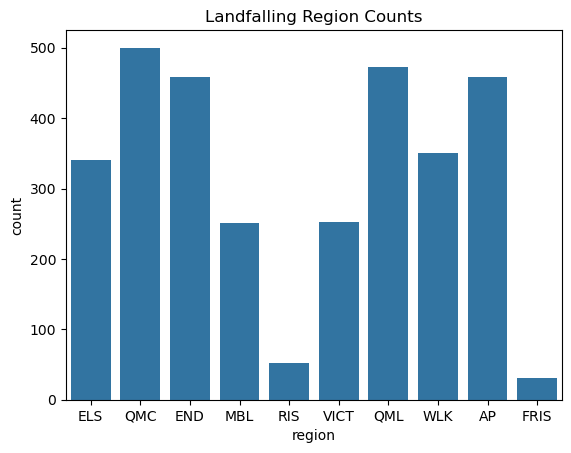

In [100]:
sns.countplot(landfalling_catalog, x='region')
plt.title('Landfalling Region Counts')

In [119]:
# getting areas of each region, in km2
region_areas = {}

for label, mask in region_masks.items():
    region_areas[label] = (region_masks[label].dot(cell_areas)/(10**6)).values

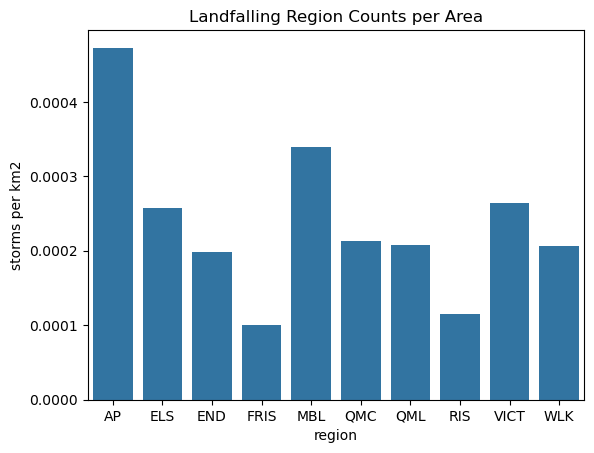

In [151]:
region_df = landfalling_catalog.groupby('region').size()
region_df = pd.concat([region_df.rename('count'), pd.Series(region_areas).rename('area')], axis=1, names=['region', 'area'])
region_df['storms_per_area'] = region_df['count']/region_df['area']
sns.barplot(data=region_df, x=region_df.index, y='storms_per_area')
plt.ylabel('storms per km2')
plt.xlabel('region')
plt.title('Landfalling Region Counts per Area');

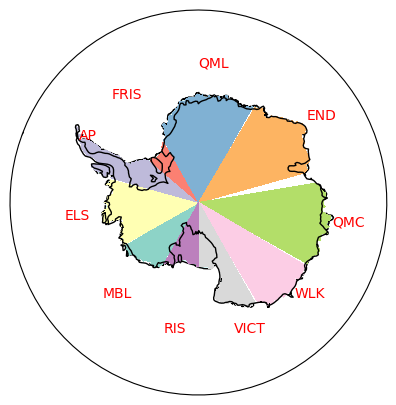

In [101]:
fig, ax = plt.subplots(figsize=(10,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
i = 0
da_lst = []
color_mapping = {}
for label, mask in region_masks.items():
    mask = mask.sel(lat=slice(-90, -39))
    no_zeros = mask.where(mask)

    color_mapping[label] = Set3(i)
    
    da_lst.append(no_zeros)
    ax.contourf(mask.lon, mask.lat, no_zeros.values, transform=ccrs.PlateCarree(), colors=[Set3(i)], zorder=30)
    ax.text((region_defs[label][0] + region_defs[label][1])/2, -65, label, transform=ccrs.PlateCarree(), color='red', zorder=40)
    i += 1

ax.set_extent([-180,180,-90,-55], ccrs.PlateCarree())
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax.coastlines(resolution='110m',linewidth=1,zorder=32)

# Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
#ax.gridlines(alpha=0.5, zorder=33);



In [102]:
years = landfalling_catalog.start_date.dt.year
landfalling_catalog['landfalling_year'] = years
year_df = landfalling_catalog.groupby('landfalling_year', as_index=False).size()

/tmp/ipykernel_604664/2305627537.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  landfalling_catalog['landfalling_year'] = years


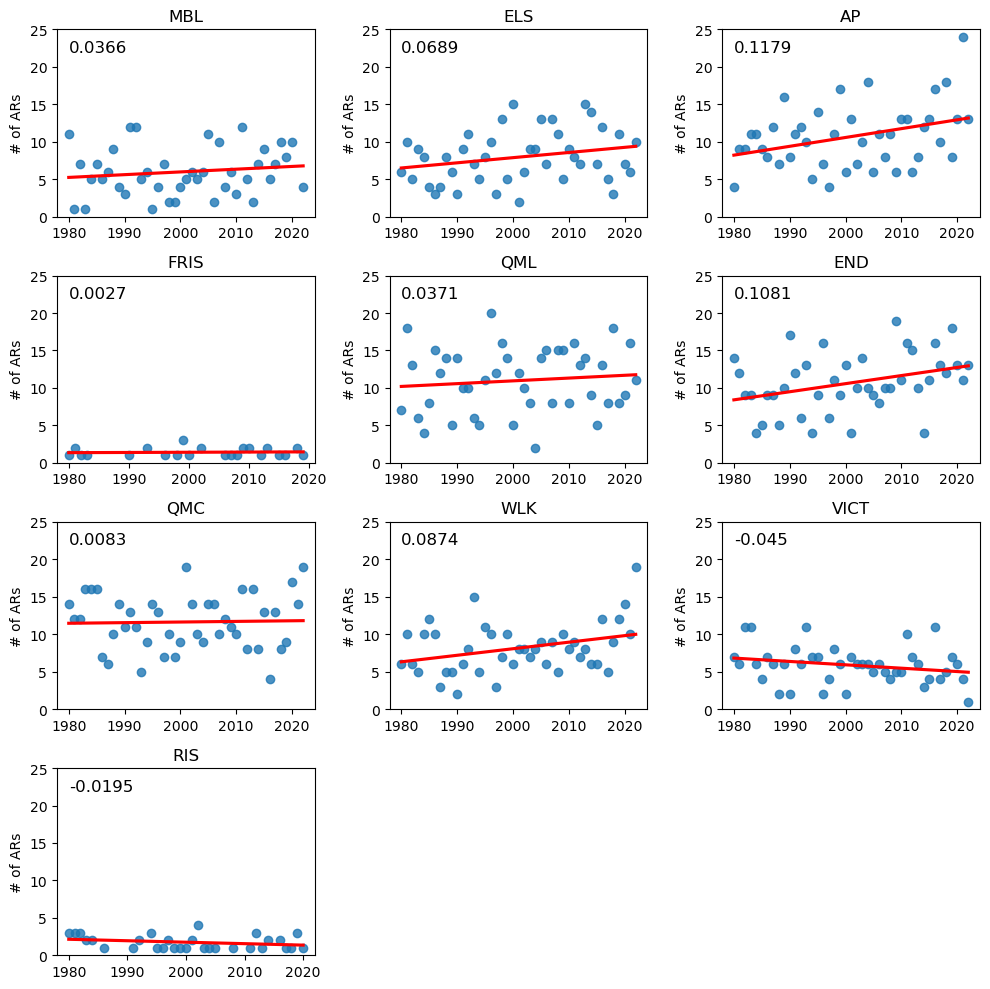

In [103]:
year_df = landfalling_catalog.groupby(['landfalling_year', 'region'], as_index=False).size()
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(10,10))
coord = 0
for label in region_masks.keys():
    cur_ax =axs[coord//3, coord%3]
    year_region_df = year_df[year_df.region == label]
    sns.regplot(data=year_region_df, x='landfalling_year', y='size', ci=None, line_kws={"color": "red"}, ax=cur_ax)
    text = round(stats.linregress(year_region_df.landfalling_year, year_region_df['size'])[0], 4)
    cur_ax.set_title(label)
    cur_ax.set_ylim([0, 25])
    cur_ax.text(1980, 22, s=text, fontsize=12)
    cur_ax.set_xlabel('')
    cur_ax.set_ylabel('# of ARs')

    coord += 1

axs[3,1].remove()
axs[3,2].remove()
fig.tight_layout()

fig.savefig(str(home_dir) + '/plots/paper_plots/regional_count_trends.png', dpi=100)

In [104]:
# function to extract the trajectories of each AR

def extract_trajectory(ar_da):
    times = ar_da.time.values

    avg_lons = []
    avg_lats = []

    for time in times:
        
        time_slice = ar_da.sel(time=time)
        inds = np.argwhere(time_slice.values == 1)
        storm_lats = time_slice.lat[inds[:,0]]
        storm_lons = time_slice.lon[inds[:,1]]

        time_slice_coords = pd.DataFrame({'lats':storm_lats, 'lons':storm_lons})
        time_slice_coords.name = '1'
        
        avg_angle = utils.average_angle(time_slice_coords)

        avg_lons.append(avg_angle[2])
        avg_lats.append(avg_angle[1])

    trajectory_df = pd.DataFrame({'time': times, 'avg_lon': avg_lons, 'avg_lat': avg_lats})

    return trajectory_df  

In [105]:
trajectories = landfalling_catalog['data_array'].apply(extract_trajectory)

In [106]:
landfalling_catalog['trajectory'] = trajectories

/tmp/ipykernel_604664/3005781668.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  landfalling_catalog['trajectory'] = trajectories


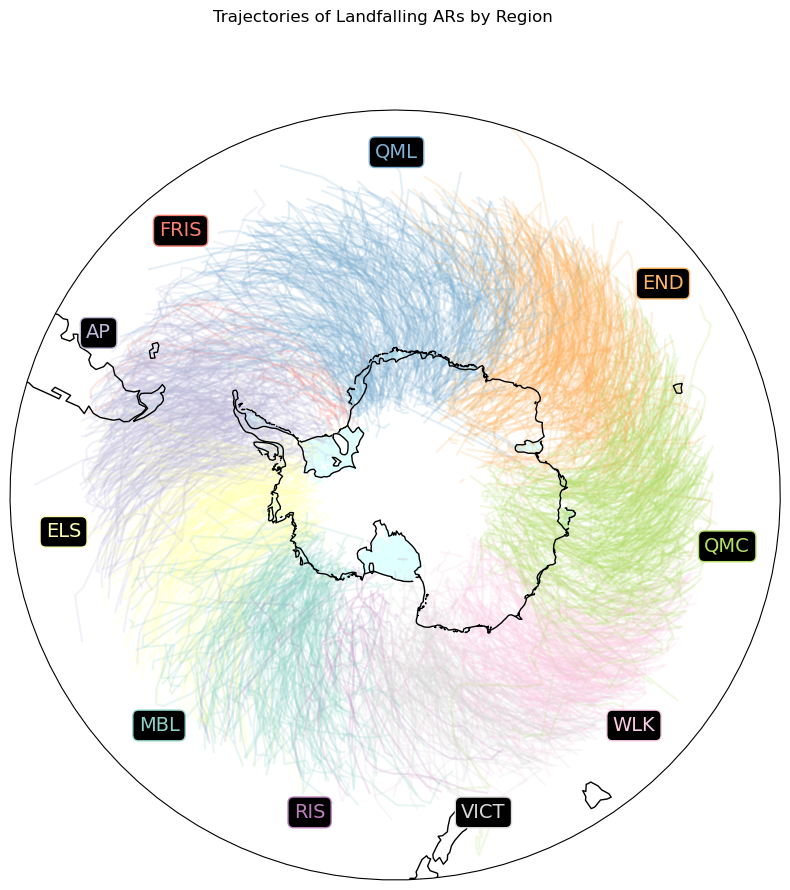

In [107]:
fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
for index, row in landfalling_catalog.iterrows():
    trajectory = row.trajectory
    ax.plot(trajectory.avg_lon, trajectory.avg_lat, transform=ccrs.Geodetic(), color=color_mapping[row.region], alpha=0.2)

for label in region_defs.keys():
    ax.text((region_defs[label][0] + region_defs[label][1])/2, -45, label, fontsize=14, horizontalalignment='center', bbox=dict(facecolor='black', edgecolor=color_mapping[label], boxstyle='round'), transform=ccrs.PlateCarree(), color=color_mapping[label], zorder=40)

ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax.coastlines(resolution='110m',linewidth=1,zorder=32)

    
# Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
#ax.gridlines(alpha=0.5, zorder=33)
fig.suptitle('Trajectories of Landfalling ARs by Region')
fig.savefig(str(home_dir) + '/plots/paper_plots/regional_trajectory_map.png', dpi=100)

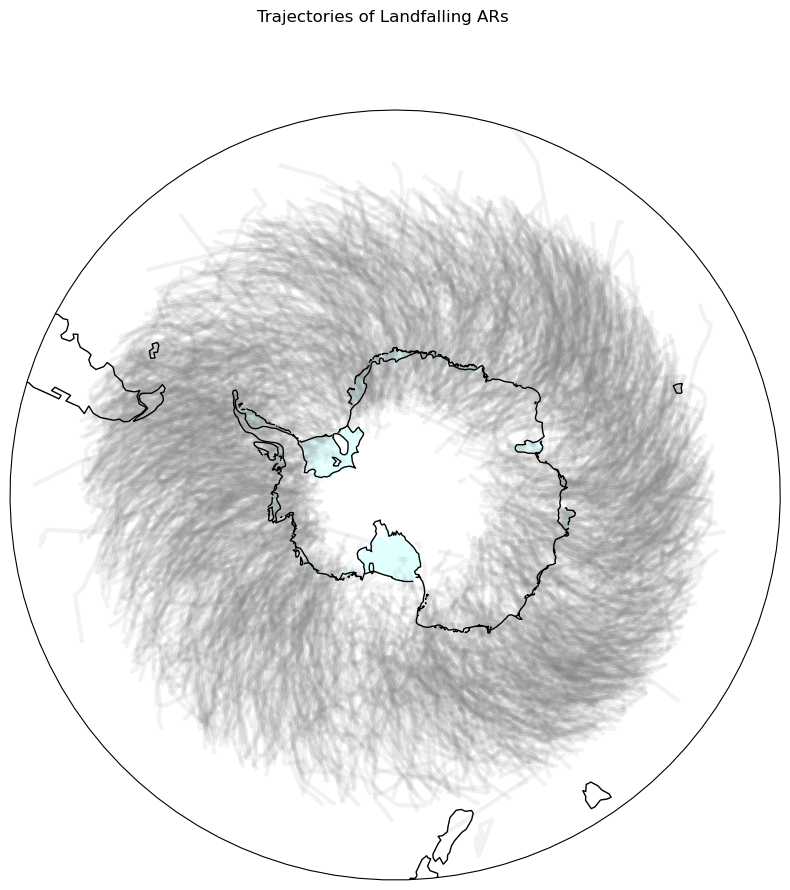

In [108]:
fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
for index, row in landfalling_catalog.iterrows():
    trajectory = row.trajectory
    ax.plot(trajectory.avg_lon, trajectory.avg_lat, transform=ccrs.Geodetic(), color='gray', alpha=0.1, linewidth=3)


ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax.coastlines(resolution='110m',linewidth=1,zorder=32)

    
# Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
#ax.gridlines(alpha=0.5, zorder=33)

fig.suptitle('Trajectories of Landfalling ARs')
fig.savefig(str(home_dir) + '/plots/paper_plots/trajectory_map.png', dpi=100)